## Train A Test A

### Classification

Category distribution:
4    15692
0    12024
3      399
2       41
5       20
1       14
6        9
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.89      0.89      0.89      2380
      Button       0.62      1.00      0.77         5
        Door       1.00      0.67      0.80         9
      Motion       0.94      0.72      0.82        80
      Socket       0.92      0.93      0.92      3161
 Temperature       1.00      1.00      1.00         3
   Vibration       1.00      0.50      0.67         2

    accuracy                           0.91      5640
   macro avg       0.91      0.82      0.84      5640
weighted avg       0.91      0.91      0.91      5640

Macro F1-Score: 0.8378


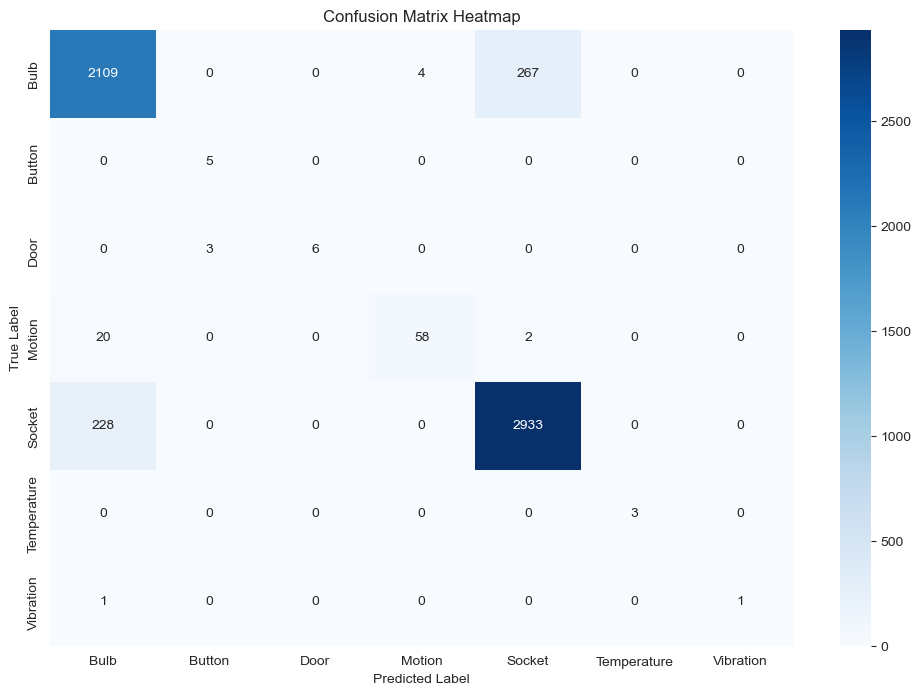

In [9]:
# Classification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_A_fix_packets.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Type"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)
# Calculated Macro Average F1-Score
f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

### Identification

Category distribution:
15    4962
14    4656
5     4463
13    3982
12    2324
8     2270
9     1537
10    1430
6     1092
7     1000
11     391
1       21
20      20
0       14
2       10
4        9
17       6
16       4
19       3
3        3
18       2
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.71      1.00      0.83         5
        Aqara Door 1       0.50      1.00      0.67         1
        Aqara Door 2       1.00      0.75      0.86         4
     Aqara Vibration       1.00      1.00      1.00         2
       Ledvance Bulb       0.81      0.83      0.82       886
Ledvance Smart+ Plug       0.81      0.76      0.78       211
    Ledvance Z3 Plug       0.72      0.66      0.69       196
           Moes Bulb       0.89      0.84      0.87       458
      Philips Lamp 1       0.66      0.49      0.56       323
      Philips Lamp 2       0.65      0.58      0.61       250
      Philips Lamp 3       0.92      

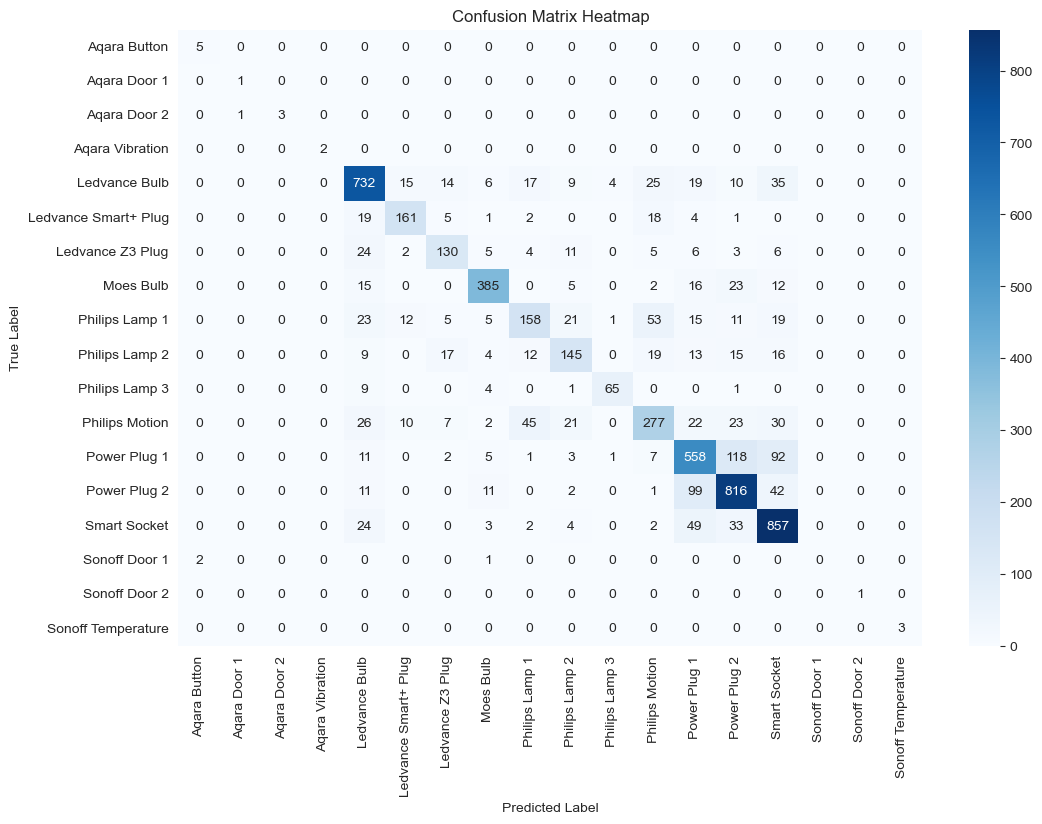

In [10]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_A_fix_packets.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Name"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))  

target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

## Train B Test B

### Classification

Category distribution:
4    24904
0    14868
3      818
1      121
2      112
5      106
6       19
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.91      0.87      0.89      2964
      Button       0.81      1.00      0.90        26
        Door       1.00      0.88      0.94        25
      Motion       0.91      0.87      0.89       167
      Socket       0.92      0.95      0.94      4975
 Temperature       1.00      0.76      0.86        29
   Vibration       1.00      1.00      1.00         4

    accuracy                           0.92      8190
   macro avg       0.94      0.90      0.92      8190
weighted avg       0.92      0.92      0.92      8190

Macro F1-Score: 0.9161


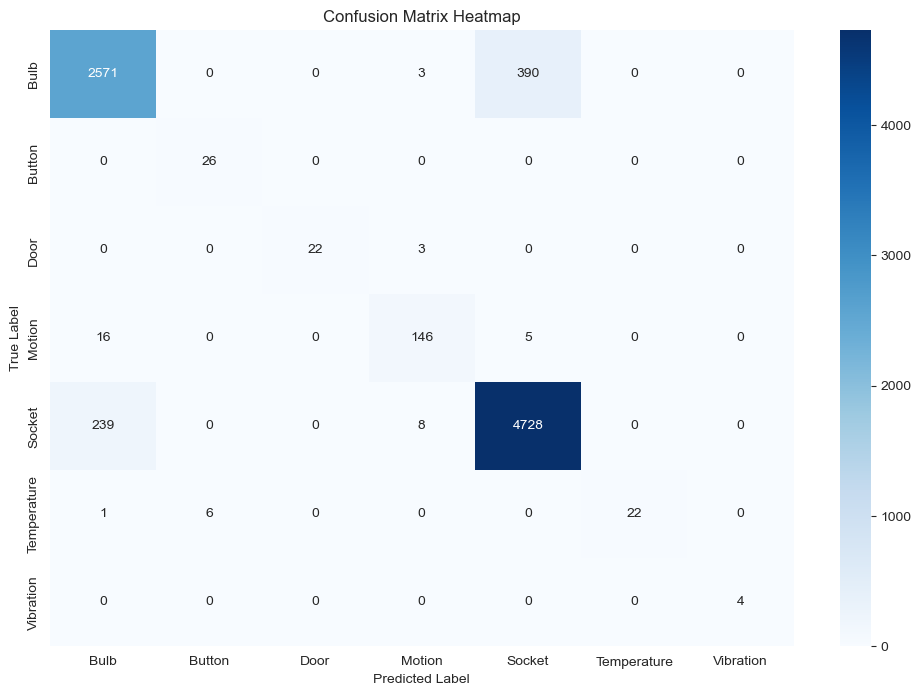

In [11]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_B_fix_packets.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Type"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))  

target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)
f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

### Identification

Category distribution:
13    8136
15    7901
14    6158
5     4644
9     3767
11    2903
8     2048
7     1806
10    1506
6      903
12     681
0      121
20     106
3       71
18      52
16      34
17      34
1       31
4       19
19      14
2       13
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.87      1.00      0.93        26
        Aqara Door 1       1.00      0.70      0.82        10
        Aqara Door 2       0.25      1.00      0.40         1
        Aqara Motion       1.00      0.93      0.96        14
     Aqara Vibration       1.00      1.00      1.00         4
       Ledvance Bulb       0.77      0.73      0.75       983
Ledvance Smart+ Plug       0.72      0.66      0.69       149
    Ledvance Z3 Plug       0.74      0.66      0.70       354
           Moes Bulb       0.83      0.82      0.82       371
      Philips Lamp 1       0.69      0.73      0.71       728
      Philips Lamp 2       0.77      

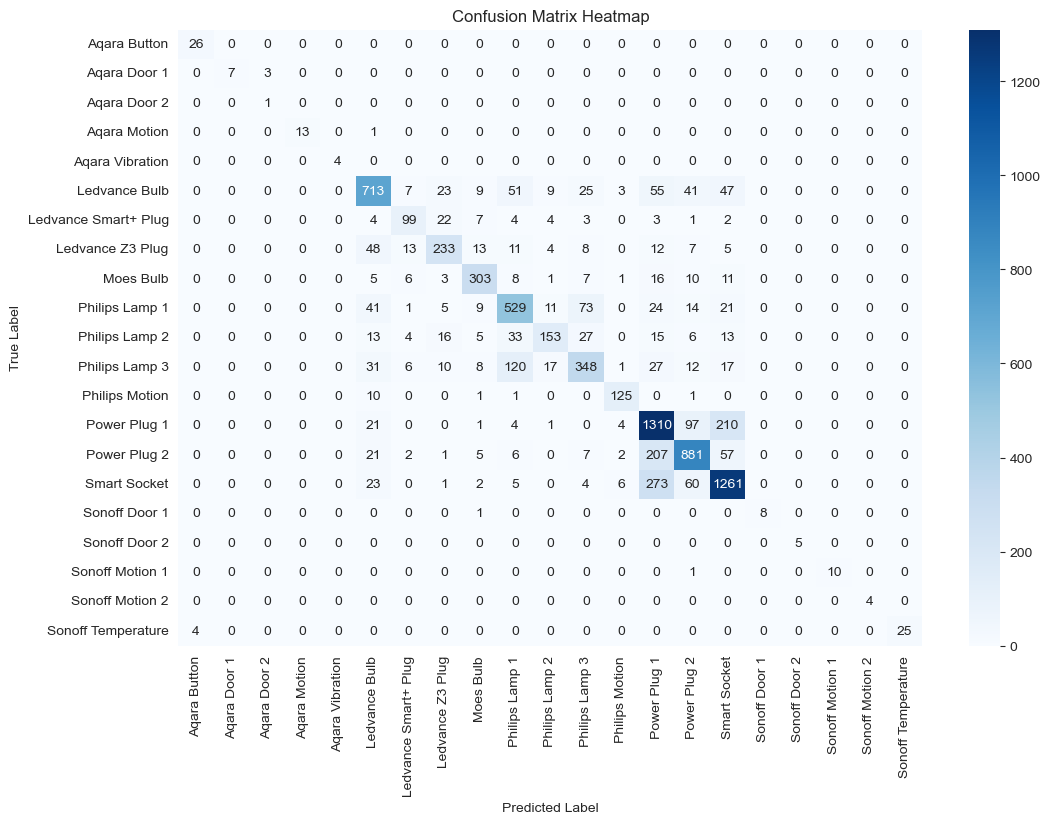

In [12]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_B_fix_packets.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Name"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))  

target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

## Train A Test B

### Classification

Category distribution:
4    15692
0    12024
3      399
2       41
5       20
1       14
6        9
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.66      0.73      0.69     14868
      Button       0.43      0.20      0.27       121
        Door       0.66      0.37      0.47       112
      Motion       0.28      0.24      0.26       818
      Socket       0.85      0.81      0.83     24904
 Temperature       0.29      0.04      0.07       106
   Vibration       0.00      0.00      0.00        19

    accuracy                           0.76     40948
   macro avg       0.45      0.34      0.37     40948
weighted avg       0.77      0.76      0.76     40948

Macro F1-Score: 0.3698


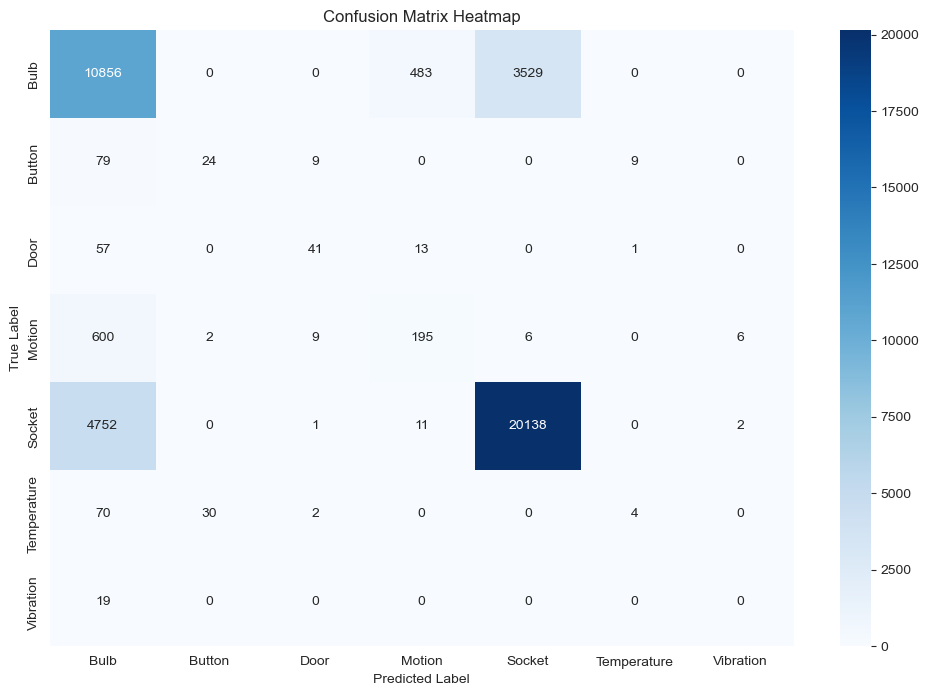

In [13]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_A_fix_packets.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Type"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_B_fix_packets.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Type"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


### Identification

Category distribution:
15    4962
14    4656
5     4463
13    3982
12    2324
8     2270
9     1537
10    1430
6     1092
7     1000
11     391
1       21
20      20
0       14
2       10
4        9
17       6
16       4
19       3
3        3
18       2
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.34      0.20      0.25       121
        Aqara Door 1       0.36      0.48      0.41        31
        Aqara Door 2       0.00      0.00      0.00        13
        Aqara Motion       0.00      0.00      0.00        71
     Aqara Vibration       0.00      0.00      0.00        19
       Ledvance Bulb       0.41      0.55      0.47      4644
Ledvance Smart+ Plug       0.14      0.10      0.12       903
    Ledvance Z3 Plug       0.31      0.30      0.31      1806
           Moes Bulb       0.37      0.39      0.38      2048
      Philips Lamp 1       0.28      0.13      0.17      3767
      Philips Lamp 2       0.09      

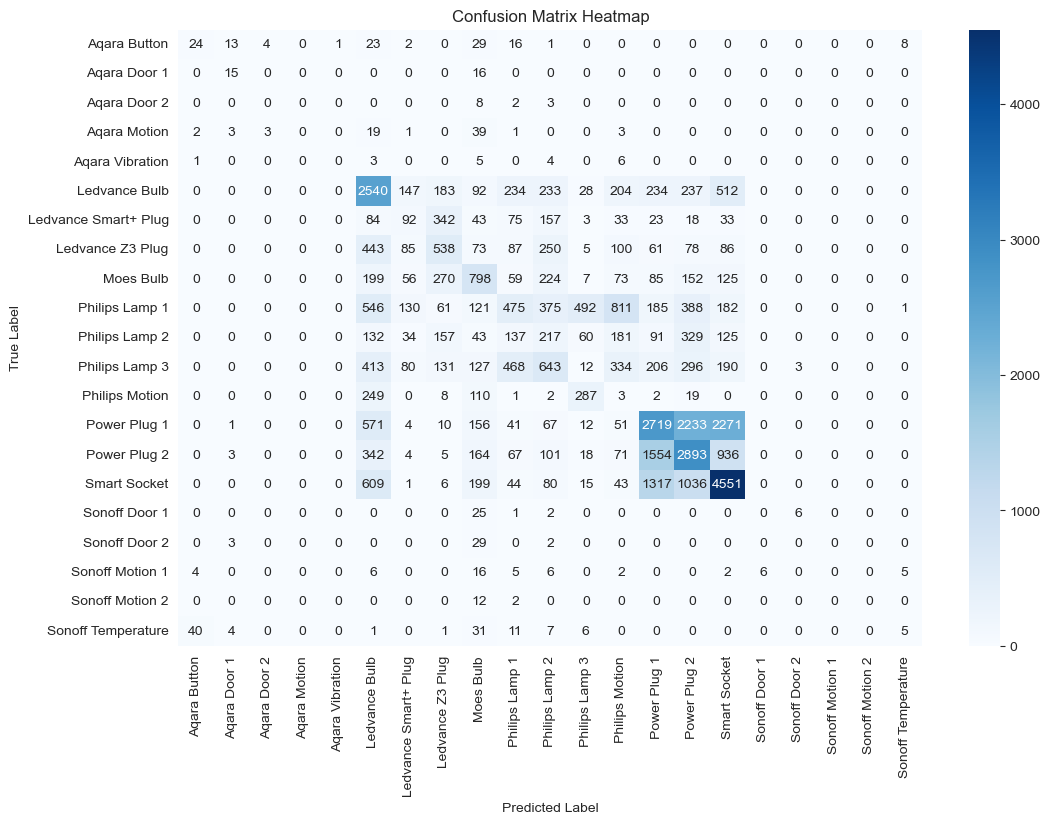

In [14]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_A_fix_packets.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Name"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_B_fix_packets.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Name"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


## Train B Test A

### Classification

Category distribution:
4    24904
0    14868
3      818
1      121
2      112
5      106
6       19
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.78      0.72      0.75     12024
      Button       0.33      0.29      0.31        14
        Door       0.50      0.17      0.25        41
      Motion       0.39      0.27      0.32       399
      Socket       0.80      0.86      0.83     15692
 Temperature       0.44      0.40      0.42        20
   Vibration       0.00      0.00      0.00         9

    accuracy                           0.79     28199
   macro avg       0.46      0.39      0.41     28199
weighted avg       0.79      0.79      0.79     28199

Macro F1-Score: 0.4114


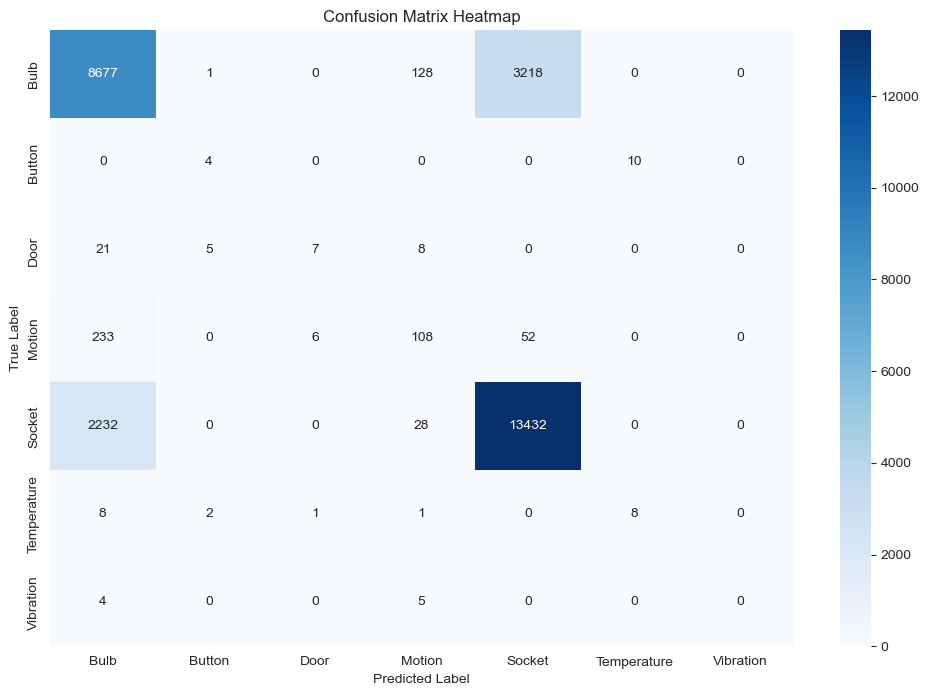

In [15]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_B_fix_packets.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Type"]
y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path = "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_A_fix_packets.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Type"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes


class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


### Identification

Category distribution:
13    8136
15    7901
14    6158
5     4644
9     3767
11    2903
8     2048
7     1806
10    1506
6      903
12     681
0      121
20     106
3       71
18      52
16      34
17      34
1       31
4       19
19      14
2       13
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.14      0.29      0.19        14
        Aqara Door 1       1.00      0.14      0.25        21
        Aqara Door 2       0.00      0.00      0.00        10
        Aqara Motion       0.29      0.67      0.40         3
     Aqara Vibration       0.00      0.00      0.00         9
       Ledvance Bulb       0.61      0.61      0.61      4463
Ledvance Smart+ Plug       0.30      0.11      0.16      1092
    Ledvance Z3 Plug       0.36      0.37      0.36      1000
           Moes Bulb       0.70      0.35      0.46      2270
      Philips Lamp 1       0.20      0.39      0.27      1537
      Philips Lamp 2       0.17      

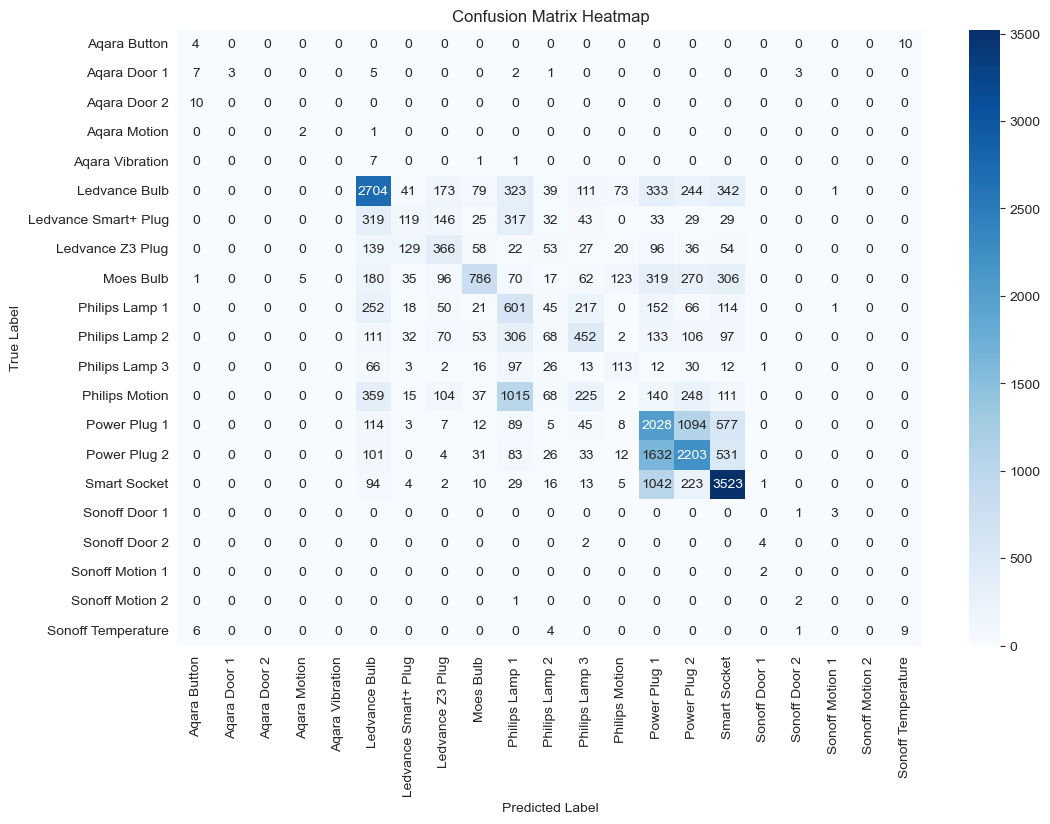

In [16]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_B_fix_packets.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Name"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_A_fix_packets.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Name"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()
